# 01 — Data Preprocessing

This notebook inspects raw datasets, runs each processor, and verifies the output schema before handing data to Part 2 (Embedding).

**Sections**
1. Configuration
2. Run processors
3. Schema verification
4. Class balance
5. Sample preview
6. Cross-dataset summary

In [6]:
import sys
import os

# Change working directory to project root
if os.getcwd().endswith('notebooks'):
    os.chdir('..')

import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.data_preprocessing import ToxigenProcessor, RussianProcessor

## 1. Configuration

Reads `configs/datasets.yaml`. Update paths there if your raw data lives elsewhere.

In [7]:
CONFIG_PATH = "configs/datasets.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

pre_cfg = cfg["preprocessing"]
OUTPUT_ROOT = pre_cfg["output_root"]
TEST_SIZE   = pre_cfg["test_size"]
RANDOM_STATE = pre_cfg["random_state"]

print("Output root :", OUTPUT_ROOT)
print("Test size   :", TEST_SIZE)
print("Random state:", RANDOM_STATE)

Output root : outputs/1_preprocessed
Test size   : 0.2
Random state: 42


## 2. Run Processors

Each processor loads raw data, normalises it to `{text, group, label}` and saves `full.csv`, `train.csv`, `test.csv` under `outputs/1_preprocessed/{dataset}/`.

In [8]:
# --- ToxiGen ---
tox_cfg = cfg["datasets"]["toxigen"]

toxigen_proc = ToxigenProcessor(
    data_dir=tox_cfg["data_dir"],
    groups=tox_cfg["groups"],
    output_root=OUTPUT_ROOT,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
tox_splits = toxigen_proc.process()

[toxigen] Saved 250948 samples -> outputs/1_preprocessed\toxigen
  Train: 200758 | Test: 50190
  Labels: {'no_hate': 185398, 'hate': 65550}
  Groups: ['asian', 'black', 'chinese', 'jewish', 'latino', 'lgbtq', 'mental_dis', 'mexican', 'middle_east', 'muslim', 'native_american', 'physical_dis', 'women']


In [9]:
# --- Russian ---
rus_cfg = cfg["datasets"]["russian"]

russian_proc = RussianProcessor(
    annotated_path=rus_cfg["annotated_path"],
    full_corpus_path=rus_cfg.get("full_corpus_path"),
    output_root=OUTPUT_ROOT,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)
rus_splits = russian_proc.process()

[russian] Saved 996 samples -> outputs/1_preprocessed\russian
  Train: 796 | Test: 200
  Labels: {'no_hate': 790, 'hate': 206}
  Groups: ['russian']


## 3. Schema Verification

Confirm every output has exactly the three required columns with clean values.

In [10]:
all_splits = {
    "toxigen": tox_splits,
    "russian": rus_splits,
}

for dataset, splits in all_splits.items():
    df = splits["full"]
    print(f"\n{'='*40}")
    print(f"Dataset : {dataset}")
    print(f"Columns : {df.columns.tolist()}")
    print(f"Shape   : {df.shape}")
    print(f"Dtypes  :\n{df.dtypes}")
    print(f"Nulls   : {df.isnull().sum().to_dict()}")
    print(f"Labels  : {sorted(df['label'].unique())}")
    print(f"Groups  : {sorted(df['group'].unique())}")


Dataset : toxigen
Columns : ['text', 'group', 'label']
Shape   : (250948, 3)
Dtypes  :
text     object
group    object
label    object
dtype: object
Nulls   : {'text': 0, 'group': 0, 'label': 0}
Labels  : ['hate', 'no_hate']
Groups  : ['asian', 'black', 'chinese', 'jewish', 'latino', 'lgbtq', 'mental_dis', 'mexican', 'middle_east', 'muslim', 'native_american', 'physical_dis', 'women']

Dataset : russian
Columns : ['text', 'group', 'label']
Shape   : (996, 3)
Dtypes  :
text     object
group    object
label    object
dtype: object
Nulls   : {'text': 0, 'group': 0, 'label': 0}
Labels  : ['hate', 'no_hate']
Groups  : ['russian']


## 4. Class Balance

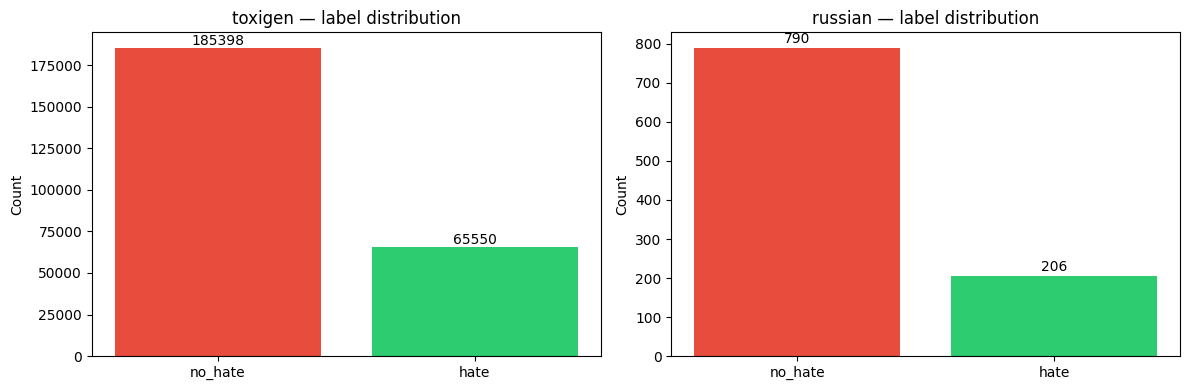

In [11]:
fig, axes = plt.subplots(1, len(all_splits), figsize=(6 * len(all_splits), 4))
if len(all_splits) == 1:
    axes = [axes]

for ax, (dataset, splits) in zip(axes, all_splits.items()):
    counts = splits["full"]["label"].value_counts()
    ax.bar(counts.index, counts.values, color=["#e74c3c", "#2ecc71"])
    ax.set_title(f"{dataset} — label distribution")
    ax.set_ylabel("Count")
    for i, (lbl, cnt) in enumerate(counts.items()):
        ax.text(i, cnt + 5, str(cnt), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

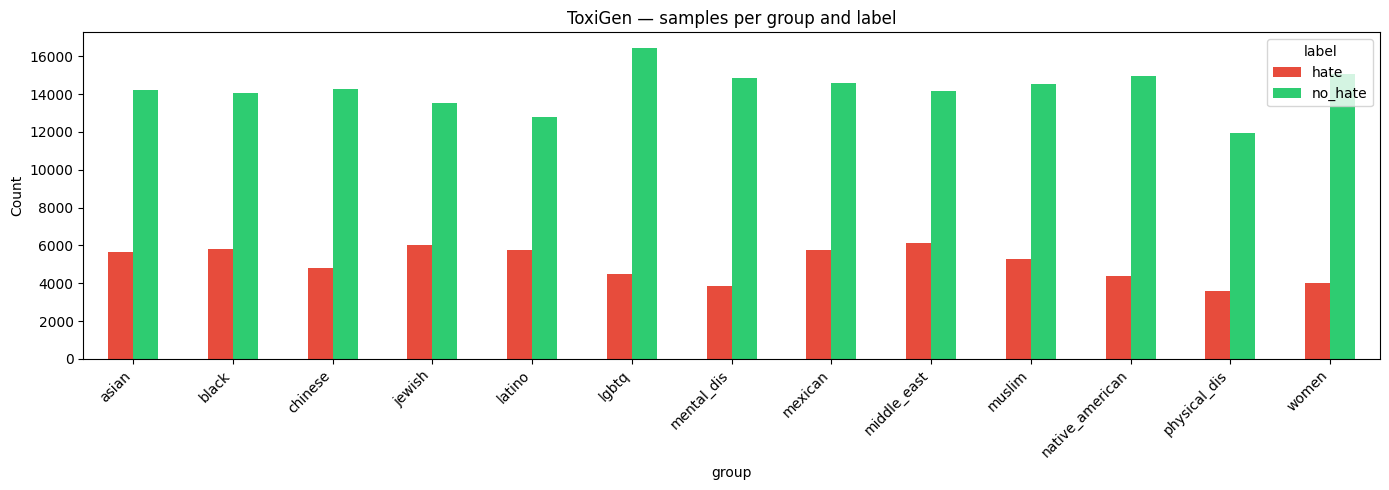

label,hate,no_hate
group,,
asian,5649,14235
black,5815,14063
chinese,4790,14269
jewish,6036,13506
latino,5744,12801
lgbtq,4503,16442
mental_dis,3829,14830
mexican,5776,14576
middle_east,6138,14159


In [13]:
# Per-group balance (ToxiGen)
df_tox = tox_splits["full"]
group_balance = (
    df_tox.groupby(["group", "label"])
    .size()
    .unstack(fill_value=0)
)
group_balance.plot(kind="bar", figsize=(14, 5), color=["#e74c3c", "#2ecc71"])
plt.title("ToxiGen — samples per group and label")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
group_balance

## 5. Sample Preview

In [14]:
print("=== ToxiGen samples ===")
display(tox_splits["full"].sample(5, random_state=42)[["text", "group", "label"]])

print("\n=== Russian samples ===")
display(rus_splits["full"].sample(5, random_state=42)[["text", "group", "label"]])

=== ToxiGen samples ===


,text,group,label
191938,"Former Muslims need to be more visible, and we...",muslim,no_hate
235340,women are mostly unwilling to admit they are w...,women,no_hate
129325,we need to increase awareness about mental ill...,mental_dis,no_hate
169203,i think the government should let people from ...,middle_east,no_hate
35964,"(The Color of Tech) I'm Jennifer Pan, the foun...",black,no_hate



=== Russian samples ===


,text,group,label
832,#naturalgas up over 20% in just 1 week!!! as t...,russian,no_hate
970,russia has taken 9 villages. they have total a...,russian,no_hate
96,you disgusting piece of shit. gonzalo is a com...,russian,hate
587,ahahaha reese’s war!! stop playing with words ...,russian,no_hate
450,"#un, #worldeconomicforum behind #global ‘war o...",russian,no_hate


## 6. Cross-Dataset Summary

In [15]:
rows = []
for dataset, splits in all_splits.items():
    df = splits["full"]
    vc = df["label"].value_counts()
    rows.append({
        "dataset": dataset,
        "total": len(df),
        "train": len(splits["train"]),
        "test": len(splits["test"]),
        "hate": vc.get("hate", 0),
        "no_hate": vc.get("no_hate", 0),
        "hate_pct": round(vc.get("hate", 0) / len(df) * 100, 1),
        "n_groups": df["group"].nunique(),
    })

summary = pd.DataFrame(rows).set_index("dataset")
display(summary)

,total,train,test,hate,no_hate,hate_pct,n_groups
dataset,,,,,,,
toxigen,250948,200758,50190,65550,185398,26.1,13
russian,996,796,200,206,790,20.7,1
